In [ ]:
#installing neccessary packages
!pip install opendatasets -q
!pip install torchsummary -q
!pip install timm -q
!pip install torchinfo -q
!pip install tqdm -q
!pip install transformers
!pip install huggingface-hub -q

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import opendatasets as od

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchsummary import summary

from collections import Counter


from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split



%matplotlib inline

# Set default aesthetics for seaborn
sns.set(style="whitegrid")

In [ ]:
#downloading the dataset using kaggle api keys
od.download("https://www.kaggle.com/datasets/dilakshanchandrasena/resized-chestxray14")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dilakshanchandrasena
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/dilakshanchandrasena/resized-chestxray14


100%|██████████| 3.95G/3.95G [01:30<00:00, 46.8MB/s]

In [ ]:
data_path = "/content/resized-chestxray14"
images_path = os.path.join(data_path, "chestx-ray14/content/chestxray14_resized")
df = pd.read_csv(os.path.join(data_path, "Data_Entry_2017.csv"))


In [ ]:
print("Total images:", len(df))
df.head()

Total images: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
memory usage: 10.3+ MB


In [ ]:
df["Finding Labels"] = df["Finding Labels"].apply(lambda x: x.split('|'))
df["No Finding"] = df["Finding Labels"].apply(lambda x: 1 if x == ['No Finding'] else 0)
df.drop(columns=["Unnamed: 11"], inplace=True)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],No Finding
0,00000001_000.png,[Cardiomegaly],0,1,58,M,PA,2682,2749,0.143,0.143,0
1,00000001_001.png,"[Cardiomegaly, Emphysema]",1,1,58,M,PA,2894,2729,0.143,0.143,0
2,00000001_002.png,"[Cardiomegaly, Effusion]",2,1,58,M,PA,2500,2048,0.168,0.168,0
3,00000002_000.png,[No Finding],0,2,81,M,PA,2500,2048,0.171,0.171,1
4,00000003_000.png,[Hernia],0,3,81,F,PA,2582,2991,0.143,0.143,0


In [ ]:
#checking missing values or null values
print("\nMissing values per column:")
print(df.isnull().sum())

# Data types and quick stats
print("\nData Info:")
print(df.info())




Missing values per column:
Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
No Finding                     0
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender        

                    Count
No Finding          60361
Infiltration        19894
Effusion            13317
Atelectasis         11559
Nodule               6331
Mass                 5782
Pneumothorax         5302
Consolidation        4667
Pleural_Thickening   3385
Cardiomegaly         2776
Emphysema            2516
Edema                2303
Fibrosis             1686
Pneumonia            1431
Hernia                227


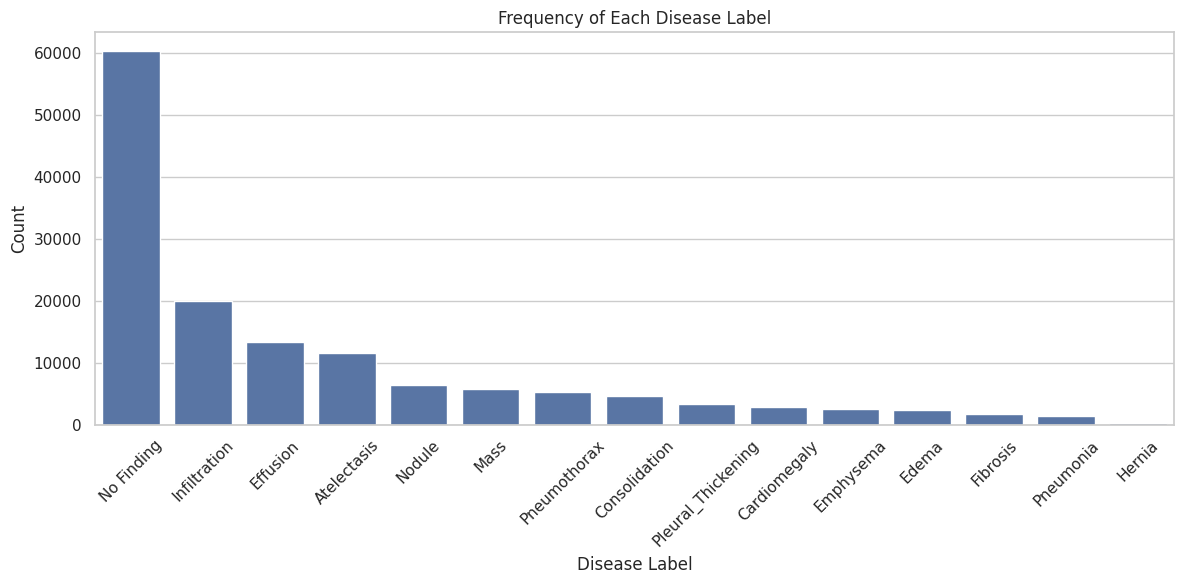

In [ ]:
all_classes = [label for sublist in df["Finding Labels"] for label in sublist]
class_counts = Counter(all_classes)
class_df = pd.DataFrame.from_dict(class_counts, orient="index", columns=["Count"])
class_df = class_df.sort_values(by='Count', ascending=False)
print(class_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_df.index, y="Count", data=class_df)
plt.xticks(rotation=45)
plt.title("Frequency of Each Disease Label")
plt.xlabel("Disease Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

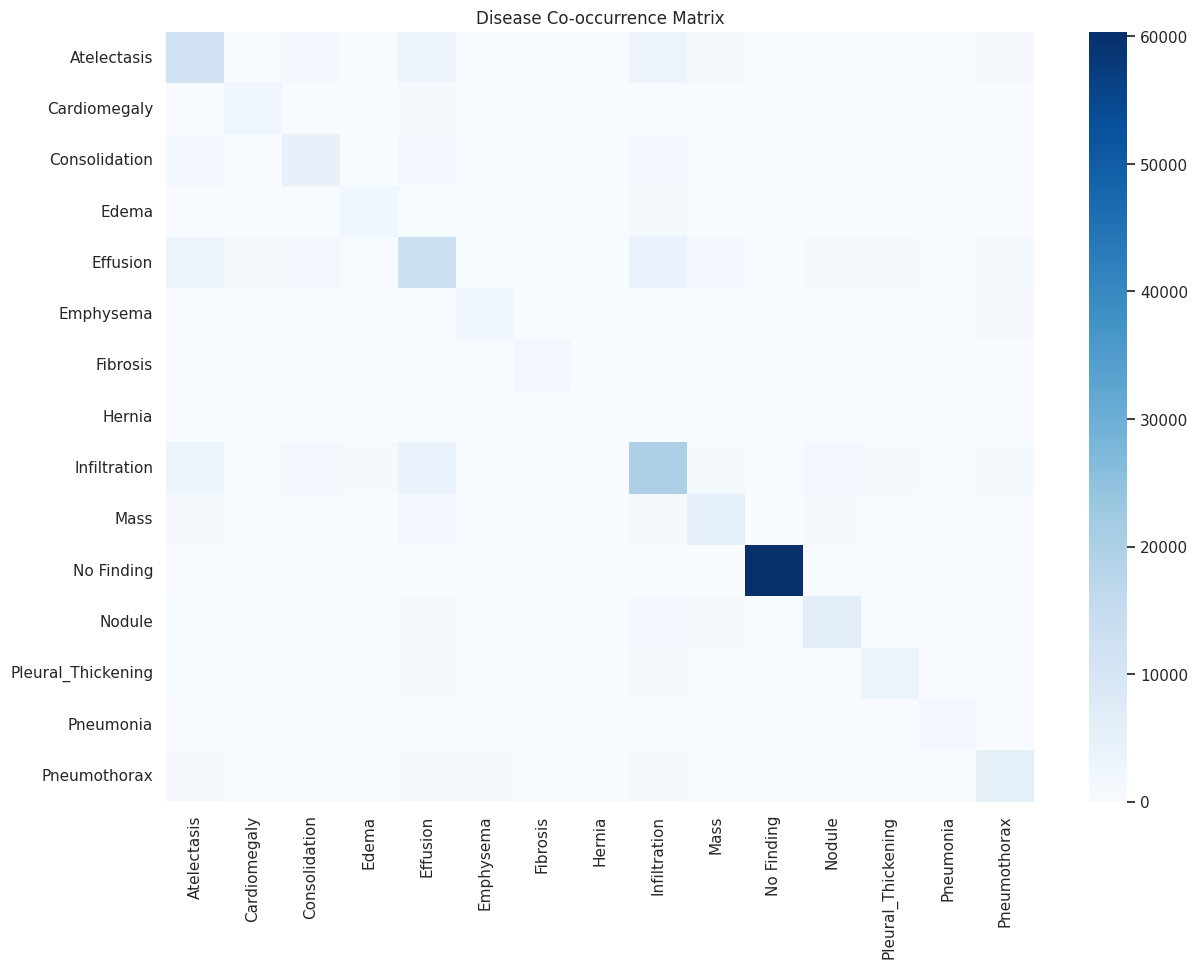

In [ ]:
mlb = MultiLabelBinarizer() #Used to convert list of labels into one-hot encoded format
label_matrix = mlb.fit_transform(df['Finding Labels'])
co_matrix = np.dot(label_matrix.T, label_matrix) #creating co-occurrence matrix to visualize disease co-occurences
co_df = pd.DataFrame(co_matrix, index=mlb.classes_, columns=mlb.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(co_df, annot=False, fmt="d", cmap="Blues")
plt.title("Disease Co-occurrence Matrix")
plt.show()

In [ ]:
label_matrix = mlb.transform(df['Finding Labels']) #transform as mlb is already fitted
label_cols = mlb.classes_
df_labels = pd.DataFrame(label_matrix, columns=label_cols)

df = df.reset_index(drop=True)
df_labels = df_labels.reset_index(drop=True)

# Drop the original 'No Finding' helper column from df before concatenation
df = df.drop(columns=["No Finding"])

df_combined = pd.concat([df, df_labels], axis=1)

In [ ]:
import os
from glob import glob
print(images_path)
def find_image_path(image_index):
    # Search recursively in all images_00x/images folders
    paths = glob(os.path.join(images_path, "images_*", "images", image_index))

    return paths[0] if paths else None

# Apply to your dataframe
df_combined["full_image_path"] = df_combined["Image Index"].apply(find_image_path)
print("Full paths of the images added to the DataFrame")

# Move 'full_image_path' column to the front
cols = df_combined.columns.tolist()
cols = cols[-1:] + cols[:-1]
df_combined = df_combined[cols]

df_combined.head()


/content/resized-chestxray14/chestx-ray14/content/chestxray14_resized
Full paths of the images added to the DataFrame


,full_image_path,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,/content/resized-chestxray14/chestx-ray14/cont...,00000001_000.png,[Cardiomegaly],0,1,58,M,PA,2682,2749,...,0,0,0,0,0,0,0,0,0,0
1,/content/resized-chestxray14/chestx-ray14/cont...,00000001_001.png,"[Cardiomegaly, Emphysema]",1,1,58,M,PA,2894,2729,...,1,0,0,0,0,0,0,0,0,0
2,/content/resized-chestxray14/chestx-ray14/cont...,00000001_002.png,"[Cardiomegaly, Effusion]",2,1,58,M,PA,2500,2048,...,0,0,0,0,0,0,0,0,0,0
3,/content/resized-chestxray14/chestx-ray14/cont...,00000002_000.png,[No Finding],0,2,81,M,PA,2500,2048,...,0,0,0,0,0,1,0,0,0,0
4,/content/resized-chestxray14/chestx-ray14/cont...,00000003_000.png,[Hernia],0,3,81,F,PA,2582,2991,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
df_combined = df_combined.drop(columns=["Follow-up #", "Patient Age","View Position","Patient Gender", "OriginalImage[Width","Height]", "OriginalImagePixelSpacing[x","y]"])

df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   full_image_path     112120 non-null  object
 1   Image Index         112120 non-null  object
 2   Finding Labels      112120 non-null  object
 3   Patient ID          112120 non-null  int64 
 4   Atelectasis         112120 non-null  int64 
 5   Cardiomegaly        112120 non-null  int64 
 6   Consolidation       112120 non-null  int64 
 7   Edema               112120 non-null  int64 
 8   Effusion            112120 non-null  int64 
 9   Emphysema           112120 non-null  int64 
 10  Fibrosis            112120 non-null  int64 
 11  Hernia              112120 non-null  int64 
 12  Infiltration        112120 non-null  int64 
 13  Mass                112120 non-null  int64 
 14  No Finding          112120 non-null  int64 
 15  Nodule              112120 non-null  int64 
 16  Pl

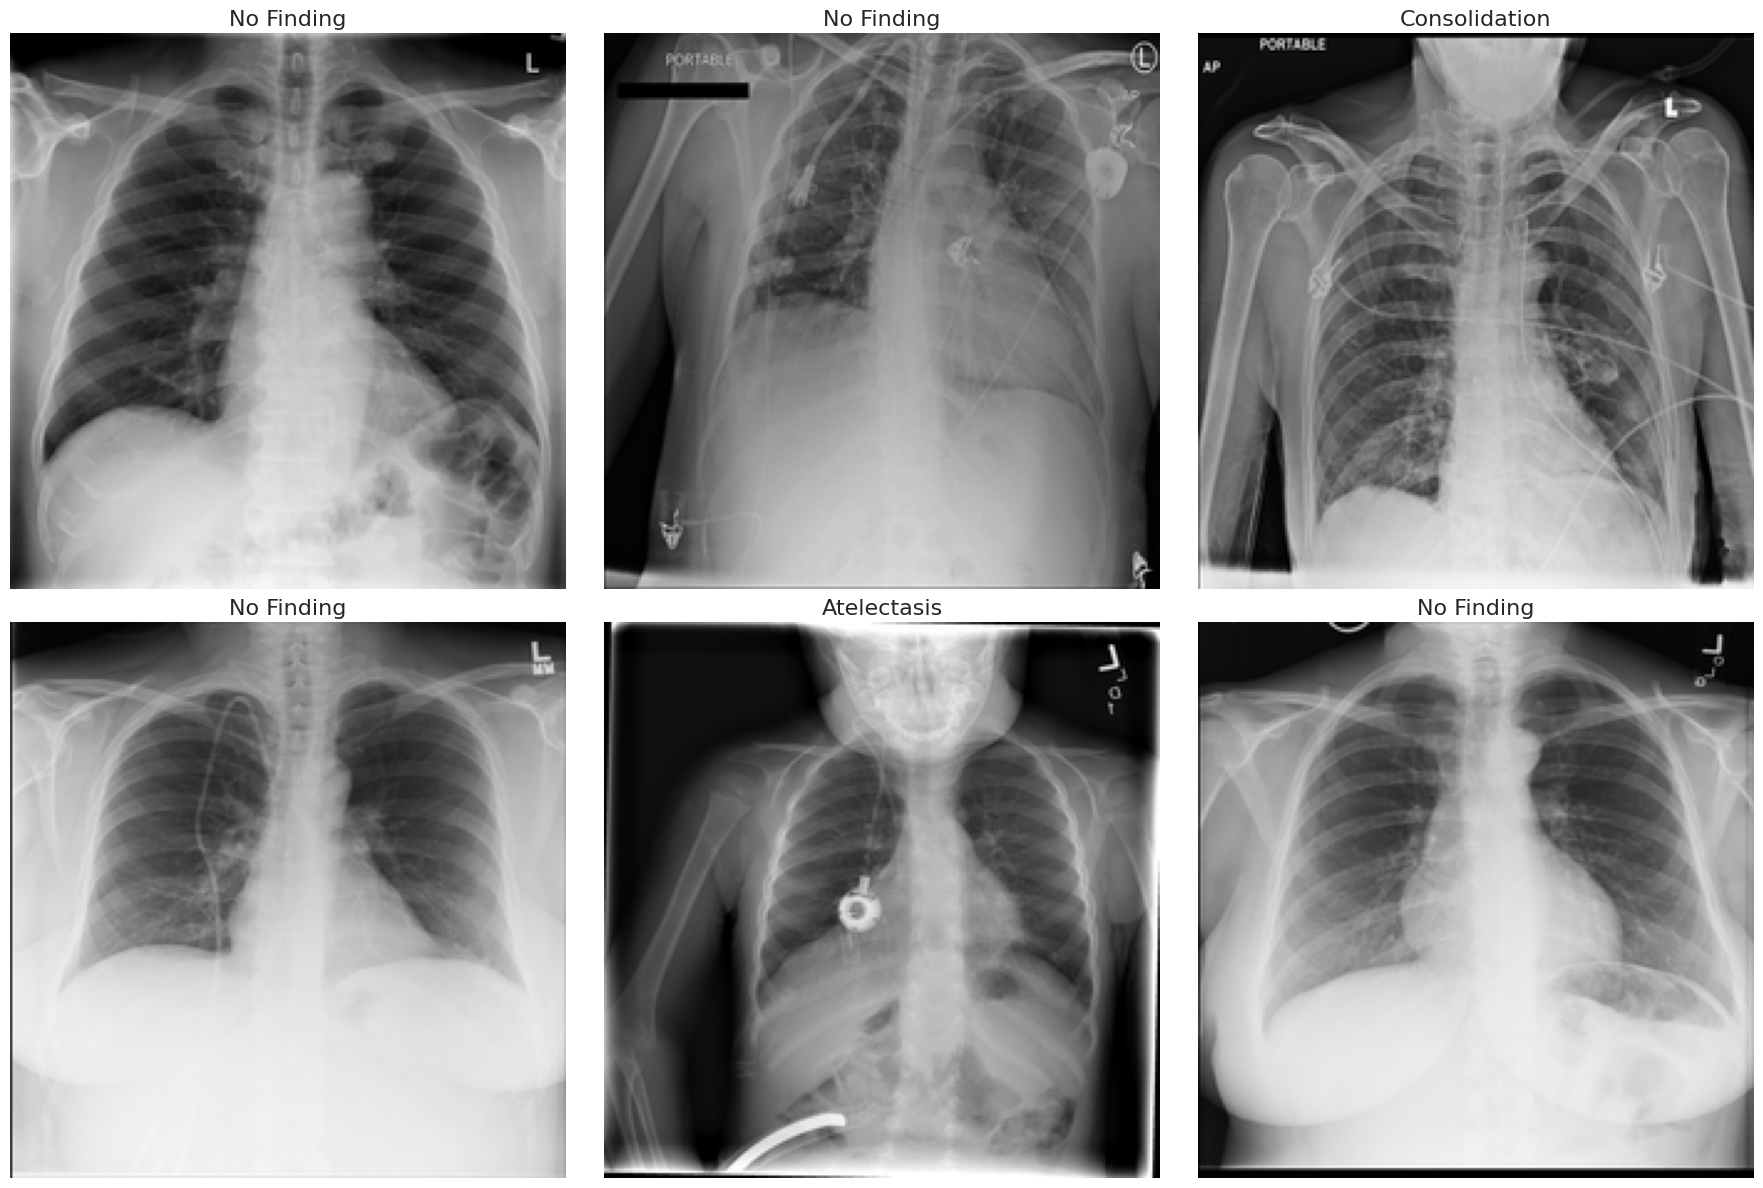

In [ ]:
from PIL import Image
import glob


def show_images(df, n_rows=2, n_cols=3):
    n_samples = n_rows * n_cols
    sample_df = df.sample(n_samples)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6)) # Adjust figsize based on rows

    for i, (idx, row) in enumerate(sample_df.iterrows()):
        img_file = row["full_image_path"]
        label = ", ".join(row["Finding Labels"])

        image_paths = glob.glob(img_file)
        if image_paths:
            img_path = image_paths[0]
            image = Image.open(img_path).resize((224, 224))
            row_idx = i // n_cols
            col_idx = i % n_cols
            axes[row_idx, col_idx].imshow(image, cmap="gray")
            axes[row_idx, col_idx].set_title(label, fontsize=16)
            axes[row_idx, col_idx].axis('off')
        else:
            print(f"Image not found for {img_file}")

    plt.tight_layout()
    plt.show()

show_images(df_combined)

In [ ]:
#filtering patient
df_patients= df_combined["Patient ID"].unique()

train_val_patients, test_patients = train_test_split(
    df_patients, test_size=0.20, random_state=42
)

train_patients , val_patients = train_test_split(
    train_val_patients, test_size=0.125, random_state=42
)

print(f"Total patients: {len(df_patients)}")
print(f"Train patients: {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")
print(f"Test patients: {len(test_patients)}")

Total patients: 30805
Train patients: 21563
Validation patients: 3081
Test patients: 6161


In [ ]:
train_df = df_combined[df_combined["Patient ID"].isin(train_patients)].reset_index(drop=True)
val_df = df_combined[df_combined["Patient ID"].isin(val_patients)].reset_index(drop=True)
test_df = df_combined[df_combined["Patient ID"].isin(test_patients)].reset_index(drop=True)

print(f"\nDataFrame sizes:")
print(f"Train subset: {len(train_df)} images")
print(f"Validation subset: {len(val_df)} images")
print(f"Test subset: {len(test_df)} images")


DataFrame sizes:
Train subset: 78614 images
Validation subset: 11212 images
Test subset: 22294 images


In [ ]:
print("\nVerifying patient-wise split (no patient overlap)")

# Check no overlap between train and val
assert len(set(train_df["Patient ID"]) & set(val_df["Patient ID"])) == 0, "Train-Val overlap detected!"
print("No overlap between Train and Val")

# Check no overlap between train and test
assert len(set(train_df["Patient ID"]) & set(test_df["Patient ID"])) == 0, "Train-Test overlap detected!"
print("No overlap between Train and Test")

# Check no overlap between val and test
assert len(set(val_df["Patient ID"]) & set(test_df["Patient ID"])) == 0, "Val-Test overlap detected!"
print("No overlap between Val and Test")

print("\nPatient-wise split successful-no leakage!")


Verifying patient-wise split (no patient overlap)
No overlap between Train and Val
No overlap between Train and Test
No overlap between Val and Test

Patient-wise split successful-no leakage!


In [ ]:
total_images = len(df_combined)
train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

print("\n" + "="*60)
print("FINAL DATASET SPLIT STATISTICS")
print("="*60)
print(f"Total images in dataset:     {total_images:,}")
print(f"Training images:             {train_count:,} ({train_count/total_images*100:.1f}%)")
print(f"Validation images:           {val_count:,} ({val_count/total_images*100:.1f}%)")
print(f"Test images:                 {test_count:,} ({test_count/total_images*100:.1f}%)")
print(f"Sum (Train+Val+Test):        {train_count+val_count+test_count:,}")
print("="*60)

print("\nUnique patients:")
print(f"  Training:   {train_df['Patient ID'].nunique()} unique patients")
print(f"  Validation: {val_df['Patient ID'].nunique()} unique patients")
print(f"  Test:       {test_df['Patient ID'].nunique()} unique patients")
print("="*60)


FINAL DATASET SPLIT STATISTICS
Total images in dataset:     112,120
Training images:             78,614 (70.1%)
Validation images:           11,212 (10.0%)
Test images:                 22,294 (19.9%)
Sum (Train+Val+Test):        112,120

Unique patients:
  Training:   21563 unique patients
  Validation: 3081 unique patients
  Test:       6161 unique patients


In [ ]:
save_dir = "/content/nih-chest-x-ray-14-224x224-resized/processed-data-splits"
os.makedirs(save_dir, exist_ok=True)

train_df.to_csv(os.path.join(save_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(save_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(save_dir, "test.csv"), index=False)

print("Train, validation, and test CSVs saved to:", save_dir)

Train, validation, and test CSVs saved to: /content/nih-chest-x-ray-14-224x224-resized/processed-data-splits


In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir=None, transform=None, mlb=None):
        """
        preprocesses images and retuns image tensor and label vector
        """
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.mlb = mlb

        # Detect label columns
        if mlb:
            self.label_cols = mlb.classes_
        else:
            self.label_cols = [col for col in df.columns
                               if col not in ["Image Index", "Finding Labels", "No Finding", "full_path"]]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
      row = self.df.iloc[idx]

      label_vector = row[self.label_cols].values.astype("float32")
      label_vector = torch.from_numpy(label_vector) #convert np array to tensor

      # Get image path from 'full_image_path'
      if 'full_image_path' in row and pd.notna(row['full_image_path']):
          img_path = row['full_image_path']
      else:
          #throw error
          raise ValueError(f"Image path not found for index {idx} in row:\n{row}")

      # Load and transform image
      image = Image.open(img_path).convert("RGB")
      if self.transform:
          image = self.transform(image)

      return image, label_vector

In [ ]:
from torchvision import transforms

# Training transform
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # Convert 1-channel to 3-channel
    transforms.Resize((224, 224)),                 # Resize to ViT/CNN input size
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.01, contrast=0.01),# Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean/std
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transform
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
train_df = pd.read_csv(save_dir + "/train.csv")
val_df = pd.read_csv(save_dir + "/val.csv")
test_df = pd.read_csv(save_dir + "/test.csv")

In [ ]:
#preporcessing data
train_dataset = ChestXrayDataset(train_df, transform=train_transform, mlb=mlb)
val_dataset = ChestXrayDataset(val_df, transform=val_transform, mlb=mlb)
test_dataset = ChestXrayDataset(test_df, transform=val_transform, mlb=mlb)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

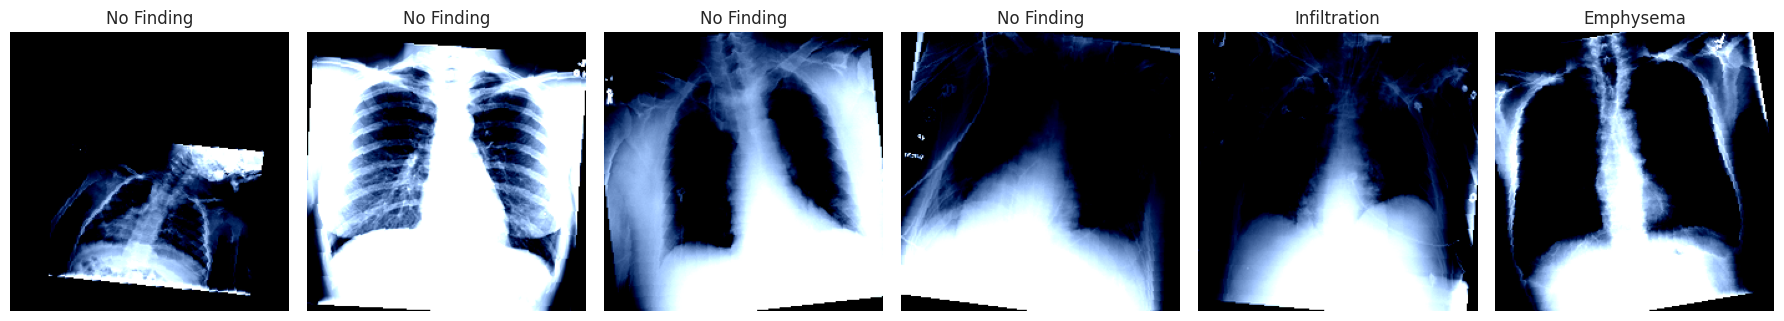

In [ ]:
def show_preprocessed_images(df,transform, n_images=6):

  """
  just for checking augmented images. Augmented images are already converted into tensors and normalised as well. Hence it might look dark.
  """
  fig, axes = plt.subplots(1, n_images, figsize=(18, 4))

  for i in range(n_images):
      row = df.sample(1).iloc[0]
      image_path = row['full_image_path']

      # Open and apply transform
      image = Image.open(image_path).convert("RGB")
      image= transform(image)


      # Convert tensor to numpy image
      np_img = image.permute(1, 2, 0).numpy()

      axes[i].imshow(np.clip(np_img, 0, 1))  # Clip for safety
      axes[i].axis('off')
      axes[i].set_title(", ".join(row["Finding Labels"]), fontsize=12)

  plt.tight_layout()
  plt.show()

# Example usage
show_preprocessed_images(df_combined, train_transform, n_images=6)

##Model Building

In [ ]:
import torch
import torch.nn as nn
import timm


class ViT(nn.Module):
    def __init__(
        self,
        model_name="vit_base_patch16_224",
        num_classes=14,              # 14 CheXpert labels
        pretrained=True,
        freeze=False,
        dropout=0.1
    ):
        super().__init__()

        # Load ViT vit
        self.vit = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0
        )
        print(self.vit)
        embed_dim = self.vit.num_features

        if freeze:
            for p in self.vit.parameters():
                p.requires_grad = False

        # Dropout for robustness
        self.dropout = nn.Dropout(dropout)

        # Multi-label classification head
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        """
        x: (B, 3, H, W)
        returns: logits (B, num_classes)
        """

        features = self.vit(x)          # (B, D)
        features = self.dropout(features)

        logits = self.classifier(features)   # (B, num_classes)

        return logits

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, value):
        score = value

        if self.best is None:
            self.best = score
            return

        improve = (score > self.best) if self.mode == "max" else (score < self.best)

        if improve:
            self.best = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True


In [ ]:
import timm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

model = ViT(num_classes=len(mlb.classes_), freeze=False).to(device)

# Loss function
criterion = nn.BCEWithLogitsLoss()


# Optimizer
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)


# LR scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

early_stopper = EarlyStopping(patience=4, mode="max")


print("Model, criterion, optimizer, and scheduler initialized successfully.")
summary(model, input_size=(1, 3, 224, 224))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

Layer (type:depth-idx)                        Output Shape              Param #
ViT                                           [1, 15]                   --
├─VisionTransformer: 1-1                      [1, 768]                  152,064
│    └─PatchEmbed: 2-1                        [1, 196, 768]             --
│    │    └─Conv2d: 3-1                       [1, 768, 14, 14]          590,592
│    │    └─Identity: 3-2                     [1, 196, 768]             --
│    └─Dropout: 2-2                           [1, 197, 768]             --
│    └─Identity: 2-3                          [1, 197, 768]             --
│    └─Identity: 2-4                          [1, 197, 768]             --
│    └─Sequential: 2-5                        [1, 197, 768]             --
│    │    └─Block: 3-3                        [1, 197, 768]             7,087,872
│    │    └─Block: 3-4                        [1, 197, 768]             7,087,872
│    │    └─Block: 3-5                        [1, 197, 768]            

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tqdm.auto import tqdm
import time
import torch.cuda.amp as amp

def train_one_epoch(model, train_loader, criterion, optimizer, epoch,
                    device, scaler, scheduler=None):

    model.train()
    running_loss = 0.0
    start_time = time.time()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch} [Train]", leave=False)

    for batch_idx, (images, targets) in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        # Forward pass with AMP
        with amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, targets)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Step LR scheduler if using OneCycleLR
        if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()


        batch_loss = loss.item()
        running_loss += batch_loss
        avg_loss = running_loss / (batch_idx + 1)
        lr = optimizer.param_groups[0]["lr"]

        pbar.set_postfix({
            "batch_loss": f"{batch_loss:.4f}",
            "avg_loss": f"{avg_loss:.4f}",
            "lr": f"{lr:.6e}"
        })

    # Epoch summary
    epoch_loss = running_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}] Train -> Loss: {epoch_loss:.4f} | Time: {elapsed:.1f}s")

    return epoch_loss

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss
from tqdm.auto import tqdm
import time
import torch.cuda.amp as amp

def validate(model, val_loader, criterion, epoch, device):
    model.eval()
    running_loss = 0.0
    start_time = time.time()

    all_logits = []
    all_targets = []

    pbar = tqdm(enumerate(val_loader), total=len(val_loader),
                desc=f"Epoch {epoch} [Val]", leave=False)

    for batch_idx, (images, targets) in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()

        with torch.no_grad(), amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, targets)

        batch_loss = loss.item()
        running_loss += batch_loss

        all_logits.append(logits.cpu())
        all_targets.append(targets.cpu())

        avg_loss = running_loss / (batch_idx + 1)
        pbar.set_postfix({"batch_loss": f"{batch_loss:.4f}",
                          "avg_loss": f"{avg_loss:.4f}"})


    val_loss = running_loss / len(val_loader)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    y_true = all_targets.numpy()
    y_prob = torch.sigmoid(all_logits).numpy()   # Apply sigmoid here

    #Compute per-class optimal thresholds
    optimal_thresholds = compute_optimal_thresholds(y_true, y_prob, step=0.01)

    #Apply thresholds
    y_pred = apply_thresholds(y_prob, optimal_thresholds)

    macro_auroc = np.nanmean([
        roc_auc_score(y_true[:, i], y_prob[:, i])
        if np.sum(y_true[:, i]) > 0 else np.nan
        for i in range(y_true.shape[1])
    ])

    micro_f1 = f1_score(y_true.flatten(), y_pred.flatten(), zero_division=0)
    ham_loss = hamming_loss(y_true, y_pred)

    elapsed = time.time() - start_time

    print(f"\nEpoch [{epoch}] Val -> Loss: {val_loss:.4f} | "
          f"Macro AUROC: {macro_auroc:.4f} | "
          f"Micro F1 (opt): {micro_f1:.4f} | "
          f"Hamming Loss: {ham_loss:.4f} | "
          f"Time: {elapsed:.1f}s")

    return val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds

In [ ]:
checkpoint_dir = "/content/drive/MyDrive/checkpoints/ablation/ViT-Only"
import os
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, macro_auroc, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'macro_auroc': macro_auroc
    }
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved: {filename}")

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def compute_optimal_thresholds(y_true, y_pred_prob, step=0.01):
    """
    Compute optimal threshold per class by maximizing F1.
    """
    num_classes = y_true.shape[1]
    thresholds = np.zeros(num_classes)

    for c in range(num_classes):
        best_thresh = 0.5
        best_f1 = 0
        y_true_c = y_true[:, c]
        y_pred_c = y_pred_prob[:, c]

        # Skip if no positive samples for stability
        if y_true_c.sum() == 0:
            thresholds[c] = best_thresh
            continue

        for t in np.arange(0, 1 + step, step):
            preds = (y_pred_c >= t).astype(int)
            f1 = f1_score(y_true_c, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = t

        thresholds[c] = best_thresh

    return thresholds


def apply_thresholds(y_pred_prob, thresholds):
    """
    Apply per-class thresholds to probabilities.
    """
    y_pred_bin = np.zeros_like(y_pred_prob, dtype=int)
    for i in range(y_pred_prob.shape[1]):
        y_pred_bin[:, i] = (y_pred_prob[:, i] >= thresholds[i]).astype(int)
    return y_pred_bin


In [ ]:
from torch import amp
import torch, os
import numpy as np

def fit(model, train_loader, val_loader, device, criterion,
        optimizer, scheduler, early_stopper,
        num_epochs=25,
        save_path="checkpoints"):

    os.makedirs(save_path, exist_ok=True)

    scaler = amp.GradScaler(enabled=(device.type == "cuda"))

    best_auc = float("-inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_auroc": [],
        "val_micro_f1": [],
        "val_hamming_loss": [],
        "optimal_thresholds": []
    }

    print("\n===== Starting Training =====")

    for epoch in range(1, num_epochs + 1):

        #training
        train_loss = train_one_epoch(
            model, train_loader, criterion,
            optimizer, epoch, device, scaler, scheduler=None
        )

        #validation
        val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds = \
            validate(model, val_loader, criterion, epoch, device)

        #saving historry
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_auroc"].append(macro_auroc)
        history["val_micro_f1"].append(micro_f1)
        history["val_hamming_loss"].append(ham_loss)
        history["optimal_thresholds"].append(optimal_thresholds.tolist())

        #Step LR Scheduler
        scheduler.step()

        #Save best model based on Macro AUROC
        if macro_auroc > best_auc and not np.isnan(macro_auroc):
            best_auc = macro_auroc
            file_name = os.path.join(save_path, f"best_model_epoch_{epoch}.pth")
            save_checkpoint(model, optimizer, epoch, macro_auroc, file_name)
            print(f"Saved best model (epoch {epoch}) with macro AUROC {macro_auroc:.4f}")

        #early stopping
        early_stopper(macro_auroc)
        if early_stopper.early_stop:
            print("\nEarly stopping triggered.\n")
            break

    print("\n===== Training Complete! =====\n")
    return history


In [ ]:
history = fit(
    model,
    train_loader,
    val_loader,
    device,
    criterion,
    optimizer,
    scheduler,
    early_stopper,
    num_epochs=25,
    save_path=checkpoint_dir
)



===== Starting Training =====


Epoch 1 [Train]:   0%|          | 0/2457 [00:00<?, ?it/s]

Epoch [1] Train -> Loss: 0.2007 | Time: 738.4s


Epoch 1 [Val]:   0%|          | 0/351 [00:00<?, ?it/s]


Epoch [1] Val -> Loss: 0.1900 | Macro AUROC: 0.7707 | Micro F1 (opt): 0.3577 | Hamming Loss: 0.1821 | Time: 51.1s
Checkpoint saved: /content/drive/MyDrive/checkpoints/ablation/ViT-Only/best_model_epoch_1.pth
Saved best model (epoch 1) with macro AUROC 0.7707


...


Epoch [11] Val -> Loss: 0.1793 | Macro AUROC: 0.8138 | Micro F1 (opt): 0.5142 | Hamming Loss: 0.1025 | Time: 48.9s


Epoch 12 [Train]:   0%|          | 0/2457 [00:00<?, ?it/s]

Epoch [12] Train -> Loss: 0.1509 | Time: 762.9s


Epoch 12 [Val]:   0%|          | 0/351 [00:00<?, ?it/s]


Epoch [12] Val -> Loss: 0.1840 | Macro AUROC: 0.8066 | Micro F1 (opt): 0.5086 | Hamming Loss: 0.1019 | Time: 50.3s

Early stopping triggered.


===== Training Complete! =====



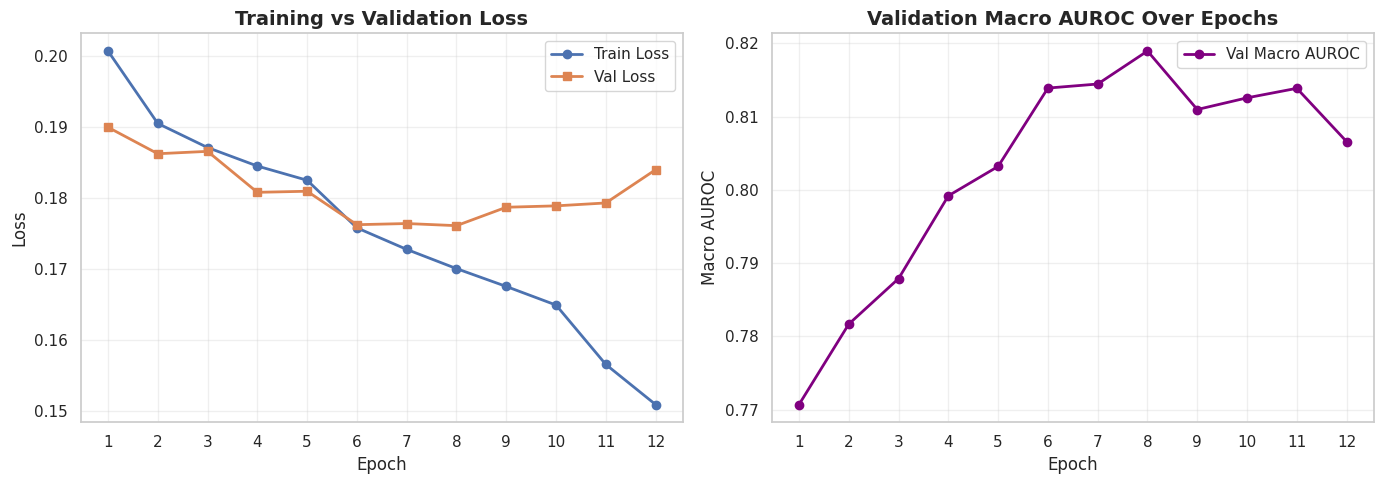

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(history):

    # Epoch indexing
    num_epochs = len(history["train_loss"])
    epochs = np.arange(1, num_epochs + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax1 = axes[0]
    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker='o', linewidth=2, markersize=6)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker='s', linewidth=2, markersize=6)

    ax1.set_title("Training vs Validation Loss", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    # Plot 2: Macro AUROC curve
    ax2 = axes[1]
    ax2.plot(epochs, history["val_macro_auroc"], label="Val Macro AUROC", color='purple',
             marker='o', linewidth=2, markersize=6)

    ax2.set_title("Validation Macro AUROC Over Epochs", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Macro AUROC", fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

In [ ]:
torch.save(model, (checkpoint_dir+"/final"))

In [ ]:
# Load (in a new session/process)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading bets model")
model_best =ViT(num_classes=len(mlb.classes_)).to(device2)      # recreate the architecture
checkpoint = torch.load("/content/drive/MyDrive/checkpoints/ablation/ViT-Only/best_model_epoch_8.pth", map_location="cpu", weights_only=False)
model_best.load_state_dict(checkpoint['model_state_dict'])
model_best.eval()                      # important for inference

Loading bets model
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p

ViT(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(a

In [ ]:
del(model_best)

In [ ]:

def plot_roc_curves(y_true, y_prob, class_names):
    n_classes = y_true.shape[1]
    plt.figure(figsize=(16, 12))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    # Plot micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='black', lw=3, linestyle='--',
             label=f'Micro-average ROC curve (AUC = {roc_auc_micro:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves per Class and Micro-average')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.show()


In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss, classification_report, roc_curve, auc
import matplotlib.pyplot as plt


def evaluate_test_set(model, test_loader, device, class_names, val_optimal_thresholds=None):
    model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = targets.to(device)
            model_output = model(images)
            logits = model_output
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

    y_true = torch.cat(all_targets).numpy()
    y_prob = torch.sigmoid(torch.cat(all_logits)).numpy()

    # Exclude 'No Finding' class
    ignore_class = "No Finding"
    if ignore_class in class_names:
        no_find_idx = class_names.index(ignore_class)
        keep_indices = [i for i in range(len(class_names)) if i != no_find_idx]
    else:
        keep_indices = list(range(len(class_names)))

    y_true = y_true[:, keep_indices]
    y_prob = y_prob[:, keep_indices]
    class_names = [class_names[i] for i in keep_indices]

    # Use validation-set thresholds if provided
    if val_optimal_thresholds is not None:
        thresholds = val_optimal_thresholds[keep_indices]
        print("Using validation-set optimal thresholds excluding 'No Finding'.")
    else:
        thresholds = compute_optimal_thresholds(y_true, y_prob, step=0.01)
        print("Computed optimal thresholds on test set (excluding 'No Finding').")
    print(np.round(thresholds, 3))

    y_pred = apply_thresholds(y_prob, thresholds)

    macro_auc = np.nanmean([
        roc_auc_score(y_true[:, i], y_prob[:, i]) if np.sum(y_true[:, i]) > 0 else np.nan
        for i in range(y_true.shape[1])
    ])

    micro_f1 = f1_score(y_true.flatten(), y_pred.flatten(), zero_division=0)
    ham_loss = hamming_loss(y_true, y_pred)

    print("\nTest Set Metrics (excluding 'No Finding'):")
    print(f"Macro AUROC: {macro_auc:.4f}")
    print(f"Micro F1-score: {micro_f1:.4f}")
    print(f"Hamming Loss: {ham_loss:.4f}\n")

    print("Detailed Classification Report (excluding 'No Finding'):")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    plot_roc_curves(y_true, y_prob, class_names)

    return {
        "macro_auc": macro_auc,
        "micro_f1": micro_f1,
        "hamming_loss": ham_loss,
        "optimal_thresholds": thresholds
    }


Using validation-set optimal thresholds excluding 'No Finding'.
[0.16 0.17 0.11 0.08 0.21 0.18 0.1  0.01 0.18 0.25 0.13 0.06 0.04 0.2 ]

Test Set Metrics (excluding 'No Finding'):
Macro AUROC: 0.7992
Micro F1-score: 0.3158
Hamming Loss: 0.1042

Detailed Classification Report (excluding 'No Finding'):
                    precision    recall  f1-score   support

       Atelectasis       0.23      0.60      0.33      2207
      Cardiomegaly       0.30      0.44      0.36       618
     Consolidation       0.13      0.58      0.21       951
             Edema       0.15      0.50      0.23       454
          Effusion       0.43      0.55      0.48      2553
         Emphysema       0.40      0.21      0.28       531
          Fibrosis       0.21      0.02      0.04       364
            Hernia       0.06      0.17      0.09        48
      Infiltration       0.31      0.57      0.40      4097
              Mass       0.41      0.17      0.24      1076
            Nodule       0.19      0.

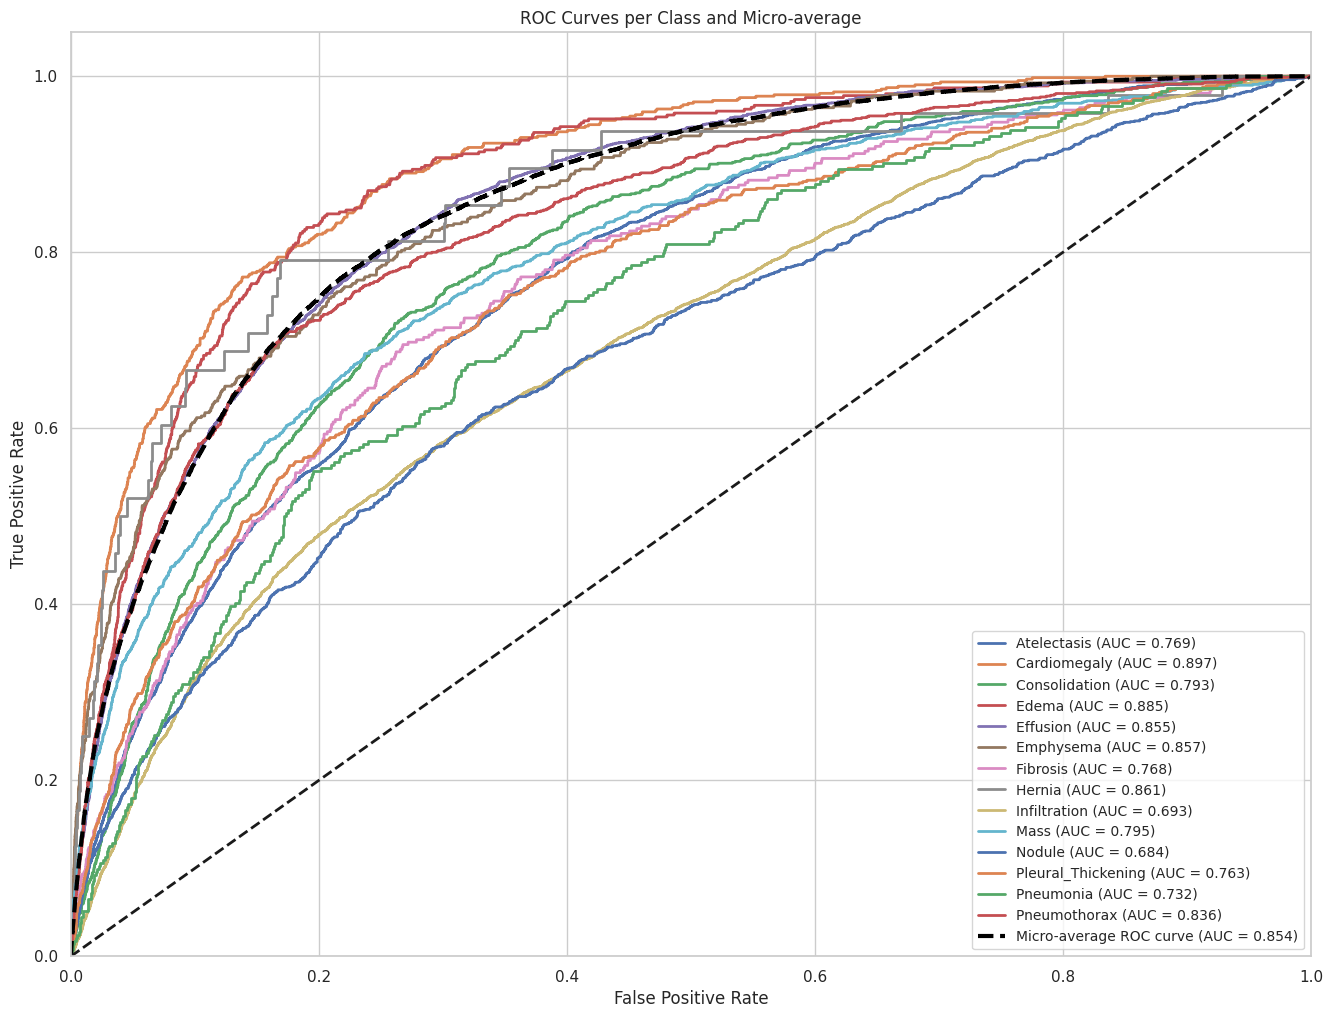

In [ ]:
threshold = history["optimal_thresholds"][7]
results = evaluate_test_set(model_best, test_loader, device, mlb.classes_.tolist(),np.array(threshold))